## **Imports and Setup**

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

***
### **Data Loading & Labeling**

In [2]:
fake=pd.read_csv("data/raw/politifact_fake.csv")
real=pd.read_csv("data/raw/politifact_real.csv")
print(f"fake data shape: {fake.shape} Real data shape: {real.shape}")

fake data shape: (432, 4) Real data shape: (624, 4)


In [3]:
fake.info()
print("Null count per column:\n", fake.isnull().sum())
display(fake.head())
display(real.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         432 non-null    object
 1   news_url   428 non-null    object
 2   title      432 non-null    object
 3   tweet_ids  392 non-null    object
dtypes: object(4)
memory usage: 13.6+ KB
Null count per column:
 id            0
news_url      4
title         0
tweet_ids    40
dtype: int64


,id,news_url,title,tweet_ids
0,politifact15014,speedtalk.com/forum/viewtopic.php?t=51650,BREAKING: First NFL Team Declares Bankruptcy O...,937349434668498944\t937379378006282240\t937380...
1,politifact15156,politics2020.info/index.php/2018/03/13/court-o...,Court Orders Obama To Pay $400 Million In Rest...,972666281441878016\t972678396575559680\t972827...
2,politifact14745,www.nscdscamps.org/blog/category/parenting/467...,UPDATE: Second Roy Moore Accuser Works For Mic...,929405740732870656\t929439450400264192\t929439...
3,politifact14355,https://howafrica.com/oscar-pistorius-attempts...,Oscar Pistorius Attempts To Commit Suicide,886941526458347521\t887011300278194176\t887023...
4,politifact15371,http://washingtonsources.org/trump-votes-for-d...,Trump Votes For Death Penalty For Being Gay,915205698212040704\t915242076681506816\t915249...


,id,news_url,title,tweet_ids
0,politifact14984,http://www.nfib-sbet.org/,National Federation of Independent Business,967132259869487105\t967164368768196609\t967215...
1,politifact12944,http://www.cq.com/doc/newsmakertranscripts-494...,comments in Fayetteville NC,942953459\t8980098198\t16253717352\t1668513250...
2,politifact333,https://web.archive.org/web/20080204072132/htt...,"Romney makes pitch, hoping to close deal : Ele...",NaN
3,politifact4358,https://web.archive.org/web/20110811143753/htt...,Democratic Leaders Say House Democrats Are Uni...,NaN
4,politifact779,https://web.archive.org/web/20070820164107/htt...,"Budget of the United States Government, FY 2008",89804710374154240\t91270460595109888\t96039619...


In [4]:
# Assign binary labels: 0 for Fake, 1 for Real
fake['Label'] = 0
real['Label'] = 1

# Merge the 'title' and 'Label' columns into a single DataFrame
df = pd.concat([fake[['title', 'Label']], real[['title', 'Label']]], ignore_index=True)
df = df.rename(columns={'title': 'Text'})
print("before cleaning: ",df.shape)

# Drop any rows with missing text and remove exact duplicates
df = df.dropna(subset=['Text'])           
df = df.drop_duplicates(subset='Text')    
print('After cleaning:', df.shape)
print(df['Label'].value_counts())

df.head()

before cleaning:  (1056, 2)
After cleaning: (983, 2)
Label
1    555
0    428
Name: count, dtype: int64


,Text,Label
0,BREAKING: First NFL Team Declares Bankruptcy O...,0
1,Court Orders Obama To Pay $400 Million In Rest...,0
2,UPDATE: Second Roy Moore Accuser Works For Mic...,0
3,Oscar Pistorius Attempts To Commit Suicide,0
4,Trump Votes For Death Penalty For Being Gay,0


***
### **Exploratory Data Analysis (EDA)**

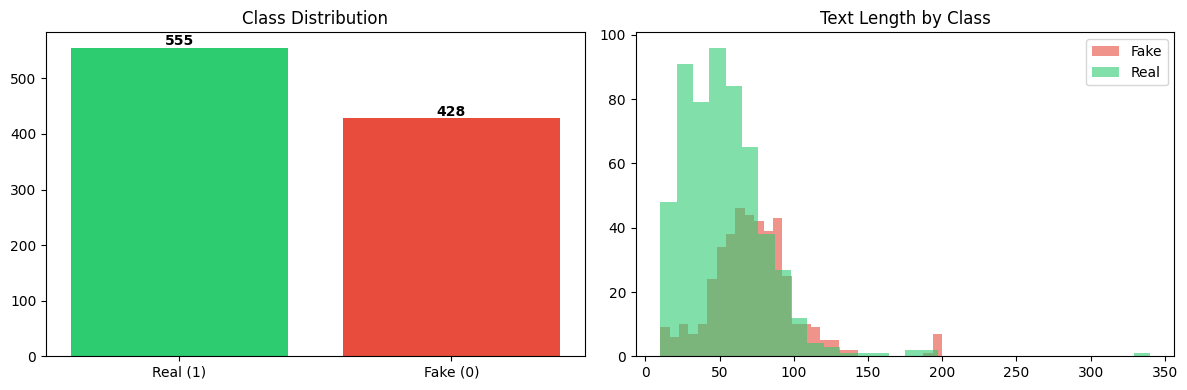

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Label'].value_counts()
axes[0].bar(['Real (1)', 'Fake (0)'], [counts[1], counts[0]], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution')
for i, v in enumerate([counts[1], counts[0]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

df['TextLength'] = df['Text'].str.len()
for label, color, name in [(0, '#e74c3c', 'Fake'), (1, '#2ecc71', 'Real')]:
    axes[1].hist(df[df['Label']==label]['TextLength'],
                 bins=30, alpha=0.6, color=color, label=name)
axes[1].set_title('Text Length by Class')
axes[1].legend()

plt.tight_layout()
plt.show()

***
### **Text Preprocessing**

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)         # remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

# Apply the cleaning function
df['clean_text'] = df['Text'].apply(clean_text)
print('Done')
print(df[['Text', 'clean_text']].head(3))

Done
                                                Text  \
0  BREAKING: First NFL Team Declares Bankruptcy O...   
1  Court Orders Obama To Pay $400 Million In Rest...   
2  UPDATE: Second Roy Moore Accuser Works For Mic...   

                                          clean_text  
0  breaking first nfl team declares bankruptcy ov...  
1   court orders obama to pay million in restitution  
2  update second roy moore accuser works for mich...  


***
### **Feature Extraction and Model Training**

In [7]:
X = df['clean_text']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,3), sublinear_tf=True, min_df=1)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Feature matrix: {X_train_vec.shape}')

Train: 786 | Test: 197
Feature matrix: (786, 14327)


In [8]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', C=100)
model.fit(X_train_vec, y_train)
print(' Model trained')

 Model trained


***
### **Model Evaluation**

Accuracy: 0.8173

              precision    recall  f1-score   support

    Fake (0)       0.77      0.84      0.80        86
    Real (1)       0.86      0.80      0.83       111

    accuracy                           0.82       197
   macro avg       0.82      0.82      0.82       197
weighted avg       0.82      0.82      0.82       197



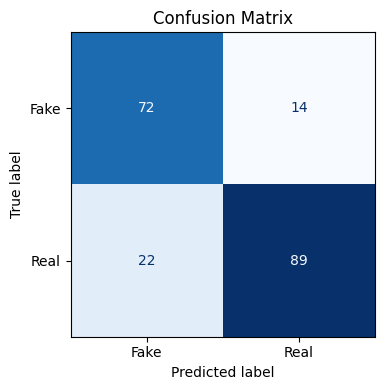

In [9]:
y_pred = model.predict(X_test_vec)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

***
### **Cross-Validation and Exporting**

In [10]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,3), sublinear_tf=True, min_df=1)),
    ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced', C=100))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
cv_f1  = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro')

print('5-Fold Cross Validation:')
print(f'  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  F1-macro : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

5-Fold Cross Validation:
  Accuracy : 0.8301 ± 0.0294
  F1-macro : 0.8273 ± 0.0288


In [11]:
pickle.dump(vectorizer, open('models/vectorizer_en.pkl', 'wb'))
pickle.dump(model,      open('models/model_en.pkl', 'wb'))
print('Saved model_en.pkl and vectorizer_en.pkl')

Saved model_en.pkl and vectorizer_en.pkl
